In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


!pip install imbalanced-learn==0.12.2

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.1
    Uninstalling imbalanced-learn-0.14.1:
      Successfully uninstalled imbalanced-learn-0.14.1


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kamilpytlak/personal-key-indicators-of-heart-disease")

print("Path to dataset files:", path)

100%|██████████| 21.4M/21.4M [00:00<00:00, 80.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kamilpytlak/personal-key-indicators-of-heart-disease/versions/6


In [34]:
data = pd.read_csv(os.path.join(path, '2022', 'heart_2022_no_nans.csv'))

In [35]:
pd.set_option('display.max_columns', None)
data

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Former smoker,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 65 to 69,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,No,No,No,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Former smoker,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 70 to 74,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,No,No,No,No,No,No,No,Yes,No,No,Yes,No,Yes,No,No,Former smoker,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 75 to 79,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,No,No,No,Yes,No,Yes,No,Yes,No,No,No,No,Yes,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246017,Virgin Islands,Male,Very good,0.0,0.0,Within past 2 years (1 year but less than 2 ye...,Yes,6.0,None of them,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 60 to 64,1.78,102.06,32.28,Yes,No,No,No,"Yes, received tetanus shot but not sure what type",No,No
246018,Virgin Islands,Female,Fair,0.0,7.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"Black only, Non-Hispanic",Age 25 to 29,1.93,90.72,24.34,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes
246019,Virgin Islands,Male,Good,0.0,15.0,Within past year (anytime less than 12 months ...,Yes,7.0,1 to 5,No,No,Yes,No,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"Multiracial, Non-Hispanic",Age 65 to 69,1.68,83.91,29.86,Yes,Yes,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,Yes
246020,Virgin Islands,Female,Excellent,2.0,2.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"Black only, Non-Hispanic",Age 50 to 54,1.70,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No


In [32]:
data.head()

,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,PhysicalActivities,SleepHours,HadHeartAttack,HadStroke,HadAsthma,HadSkinCancer,HadKidneyDisease,DifficultyWalking,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HeartAttack_enc,State_Alaska,State_Arizona,State_Arkansas,State_California,State_Colorado,State_Connecticut,State_Delaware,State_District of Columbia,State_Florida,State_Georgia,State_Guam,State_Hawaii,State_Idaho,State_Illinois,State_Indiana,State_Iowa,State_Kansas,State_Kentucky,State_Louisiana,State_Maine,State_Maryland,State_Massachusetts,State_Michigan,State_Minnesota,State_Mississippi,State_Missouri,State_Montana,State_Nebraska,State_Nevada,State_New Hampshire,State_New Jersey,State_New Mexico,State_New York,State_North Carolina,State_North Dakota,State_Ohio,State_Oklahoma,State_Oregon,State_Pennsylvania,State_Puerto Rico,State_Rhode Island,State_South Carolina,State_South Dakota,State_Tennessee,State_Texas,State_Utah,State_Vermont,State_Virgin Islands,State_Virginia,State_Washington,State_West Virginia,State_Wisconsin,State_Wyoming,LastCheckupTime_Within past 2 years (1 year but less than 2 years ago),LastCheckupTime_Within past 5 years (2 years but less than 5 years ago),LastCheckupTime_Within past year (anytime less than 12 months ago),"RemovedTeeth_6 or more, but not all",RemovedTeeth_All,RemovedTeeth_None of them,HadAngina_Yes,HadCOPD_Yes,HadDepressiveDisorder_Yes,HadArthritis_Yes,"HadDiabetes_No, pre-diabetes or borderline diabetes",HadDiabetes_Yes,"HadDiabetes_Yes, but only during pregnancy (female)",DeafOrHardOfHearing_Yes,BlindOrVisionDifficulty_Yes,DifficultyConcentrating_Yes,DifficultyDressingBathing_Yes,DifficultyErrands_Yes,SmokerStatus_Current smoker - now smokes some days,SmokerStatus_Former smoker,SmokerStatus_Never smoked,ECigaretteUsage_Not at all (right now),ECigaretteUsage_Use them every day,ECigaretteUsage_Use them some days,ChestScan_Yes,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic",HIVTesting_Yes,FluVaxLast12_Yes,PneumoVaxEver_Yes,"TetanusLast10Tdap_Yes, received Tdap","TetanusLast10Tdap_Yes, received tetanus shot but not sure what type","TetanusLast10Tdap_Yes, received tetanus shot, but not Tdap",HighRiskLastYear_Yes,CovidPos_Tested positive using home test without a health professional,CovidPos_Yes
0,0,3,4.0,0.0,1,9.0,0,0,0,0,0,0,9,1.60,71.67,27.99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0
1,1,3,0.0,0.0,1,6.0,0,0,0,0,0,0,10,1.78,95.25,30.13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,0,0,0
2,1,3,0.0,0.0,0,8.0,0,0,0,0,0,1,11,1.85,108.86,31.66,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1
3,0,1,5.0,0.0,1,9.0,0,0,0,1,0,1,12,1.70,90.72,31.32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1
4,0,2,3.0,15.0,1,5.0,0,0,0,0,0,0,12,1.55,79.38,33.07,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0


In [7]:
data.tail()


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
246017,Virgin Islands,Male,Very good,0.0,0.0,Within past 2 years (1 year but less than 2 ye...,Yes,6.0,None of them,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 60 to 64,1.78,102.06,32.28,Yes,No,No,No,"Yes, received tetanus shot but not sure what type",No,No
246018,Virgin Islands,Female,Fair,0.0,7.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"Black only, Non-Hispanic",Age 25 to 29,1.93,90.72,24.34,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes
246019,Virgin Islands,Male,Good,0.0,15.0,Within past year (anytime less than 12 months ...,Yes,7.0,1 to 5,No,No,Yes,No,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"Multiracial, Non-Hispanic",Age 65 to 69,1.68,83.91,29.86,Yes,Yes,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,Yes
246020,Virgin Islands,Female,Excellent,2.0,2.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"Black only, Non-Hispanic",Age 50 to 54,1.70,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
246021,Virgin Islands,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,5.0,None of them,Yes,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,Yes,"Black only, Non-Hispanic",Age 70 to 74,1.83,108.86,32.55,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes


In [8]:
import pandas as pd
import numpy as np

numeric_cols = [
    'PhysicalHealthDays', 'MentalHealthDays',
    'SleepHours', 'HeightInMeters',
    'WeightInKilograms', 'BMI'
]

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((data[col] < lower) | (data[col] > upper)).sum()
    pct = round(n / len(data) * 100, 2)
    print(f"{col}: {n} outliers ({pct}%) | range [{round(lower,2)}, {round(upper,2)}]")

PhysicalHealthDays: 38810 outliers (15.78%) | range [-4.5, 7.5]
MentalHealthDays: 32714 outliers (13.3%) | range [-6.0, 10.0]
SleepHours: 3488 outliers (1.42%) | range [3.0, 11.0]
HeightInMeters: 830 outliers (0.34%) | range [1.4, 2.01]
WeightInKilograms: 5940 outliers (2.41%) | range [27.23, 136.06]
BMI: 7563 outliers (3.07%) | range [12.84, 43.32]


In [9]:
data.shape


(246022, 40)

In [10]:
for col in data.columns:
    print(f"Value counts for column '{col}':")
    print(data[col].value_counts())
    print("-" * 30)

Value counts for column 'State':
State
Washington              15000
Maryland                 9165
Minnesota                9161
Ohio                     8995
New York                 8923
Texas                    7408
Florida                  7315
Kansas                   6145
Wisconsin                6126
Maine                    6013
Iowa                     5672
Hawaii                   5596
Virginia                 5565
Indiana                  5502
South Carolina           5471
Massachusetts            5465
Arizona                  5462
Utah                     5373
Michigan                 5370
Colorado                 5159
Nebraska                 5107
California               5096
Connecticut              5053
Georgia                  4978
Vermont                  4845
South Dakota             4405
Montana                  4264
Missouri                 4195
New Jersey               3967
New Hampshire            3756
Puerto Rico              3589
Idaho                    3468
A

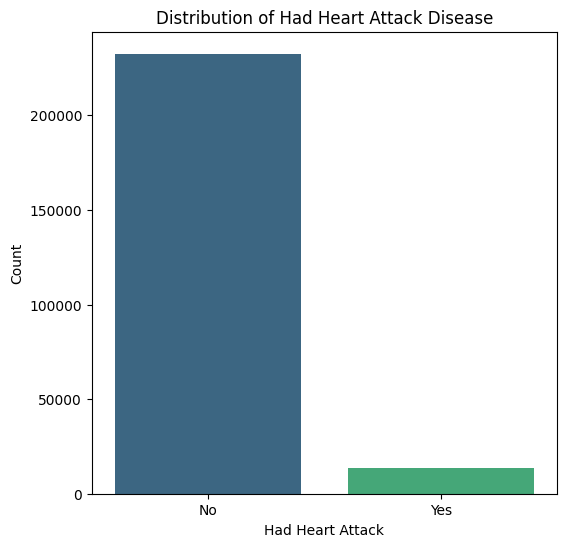

In [11]:
# Count plot for Stroke column
plt.figure(figsize=(6, 6))
sns.countplot(x='HadHeartAttack', data=data, palette='viridis')
plt.title('Distribution of Had Heart Attack Disease')
plt.xlabel('Had Heart Attack')
plt.ylabel('Count')
plt.show()

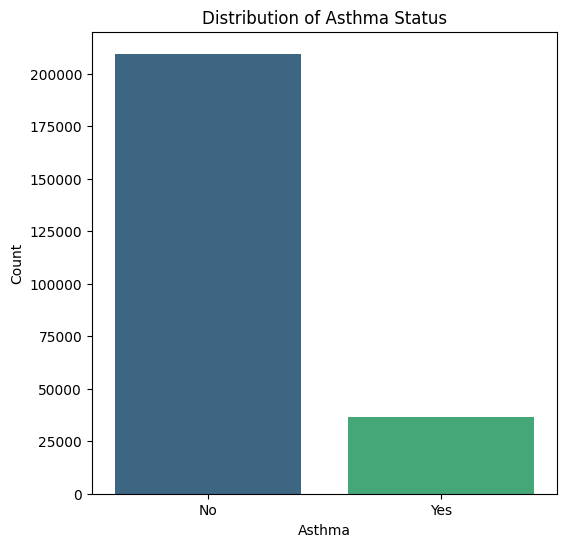

In [12]:
# Count plot for Asthma column
plt.figure(figsize=(6, 6))
sns.countplot(x='HadAsthma', data=data, palette='viridis')
plt.title('Distribution of Asthma Status')
plt.xlabel('Asthma')
plt.ylabel('Count')
plt.show()

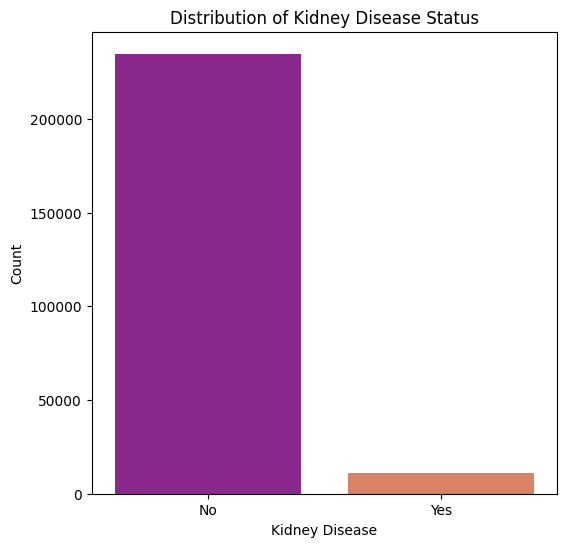

In [13]:
# Count plot for KidneyDisease column
plt.figure(figsize=(6, 6))
sns.countplot(x='HadKidneyDisease', data=data, palette='plasma')
plt.title('Distribution of Kidney Disease Status')
plt.xlabel('Kidney Disease')
plt.ylabel('Count')
plt.show()

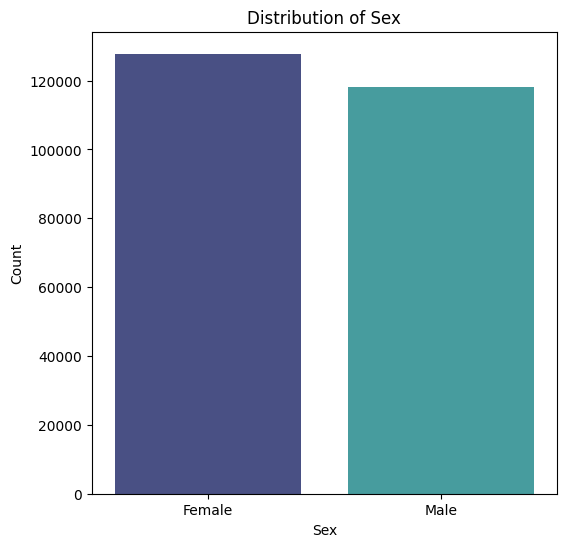

In [14]:
# Count plot for Sex column
plt.figure(figsize=(6, 6))
sns.countplot(x='Sex', data=data, palette='mako')
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

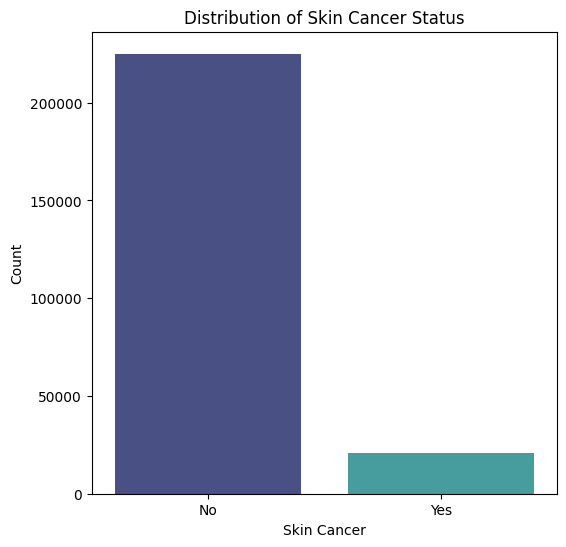

In [15]:
# Count plot for SkinCancer column
plt.figure(figsize=(6, 6))
sns.countplot(x='HadSkinCancer', data=data, palette='mako')
plt.title('Distribution of Skin Cancer Status')
plt.xlabel('Skin Cancer')
plt.ylabel('Count')
plt.show()

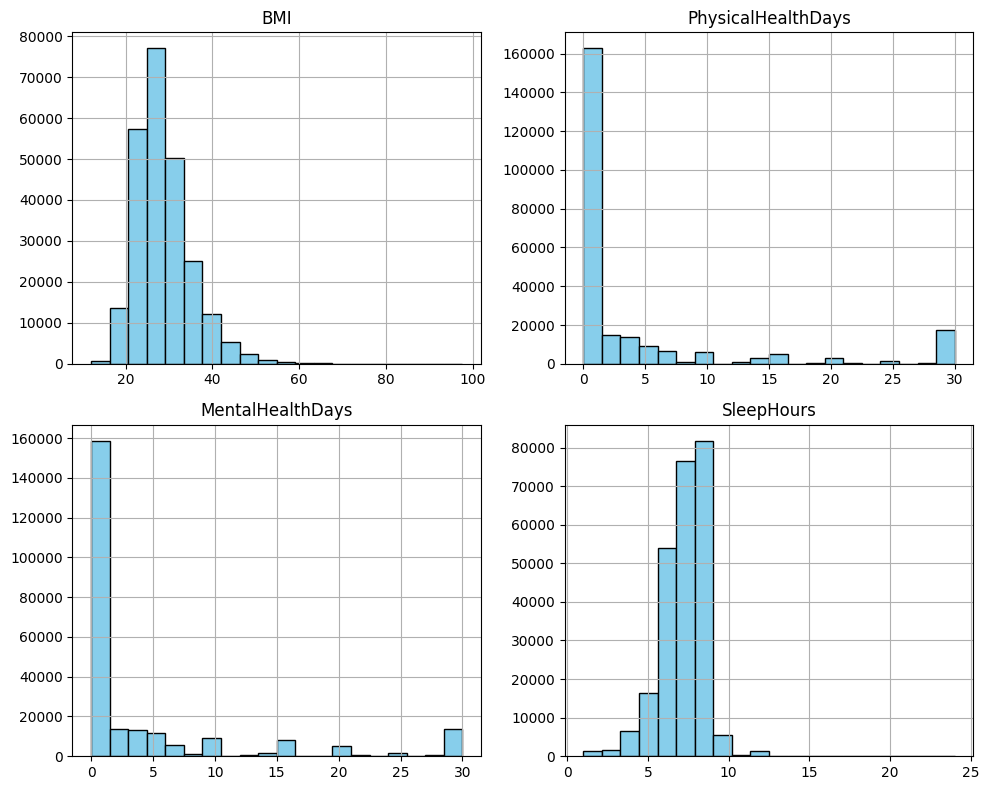

In [16]:
# Histograms for numerical columns (BMI, PhysicalHealthDays, MentalHealthDays, SleepHours)
data[['BMI', 'PhysicalHealthDays', 'MentalHealthDays', 'SleepHours']].hist(figsize=(10, 8), bins=20, color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

# Univariate — Numeric distributions

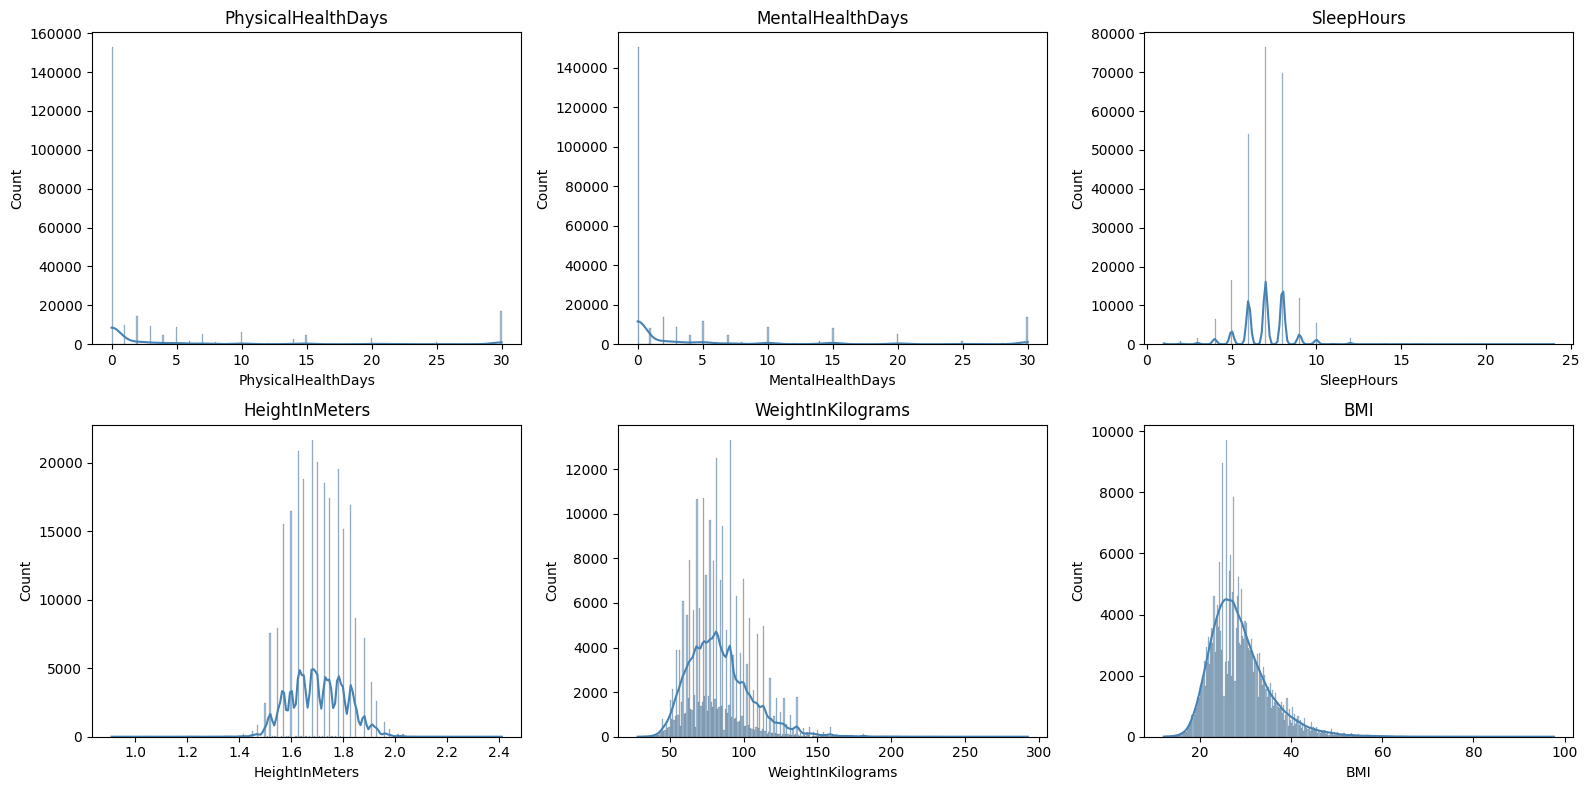

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'PhysicalHealthDays', 'MentalHealthDays',
    'SleepHours', 'HeightInMeters',
    'WeightInKilograms', 'BMI'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(data[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

#Univariate — Categorical frequencies

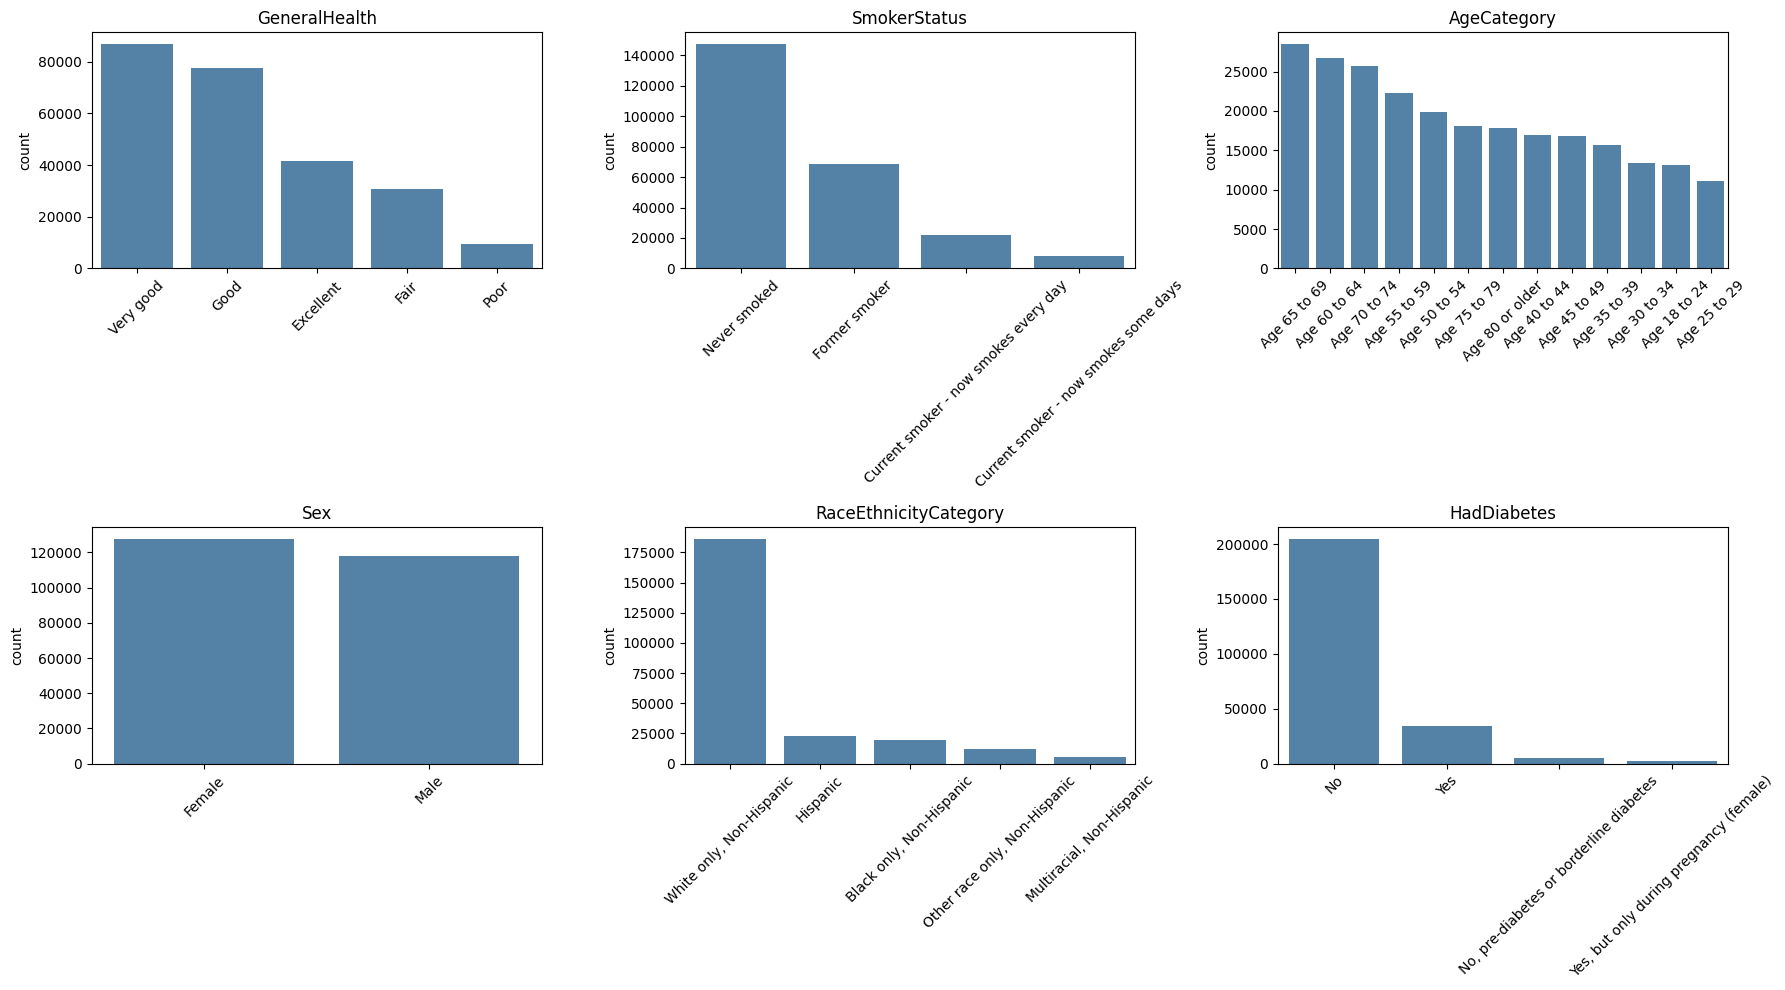

In [18]:
cat_cols = [
    'GeneralHealth', 'SmokerStatus', 'AgeCategory',
    'Sex', 'RaceEthnicityCategory', 'HadDiabetes'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    order = data[col].value_counts().index
    sns.countplot(x=col, data=data, order=order, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

#Statistical summary — skewness & kurtosis

In [19]:
print(data[numeric_cols].agg(['mean','median','std','skew','kurt']).round(2))

        PhysicalHealthDays  MentalHealthDays  SleepHours  HeightInMeters  \
mean                  4.12              4.17        7.02            1.71   
median                0.00              0.00        7.00            1.70   
std                   8.41              8.10        1.44            0.11   
skew                  2.28              2.22        0.56            0.03   
kurt                  3.97              3.86        7.21            0.01   

        WeightInKilograms    BMI  
mean                83.62  28.67  
median              81.65  27.46  
std                 21.32   6.51  
skew                 1.02   1.33  
kurt                 2.34   3.90  


#Correlation with HadHeartAttack

In [20]:
# Encode target
data['HeartAttack_enc'] = (data['HadHeartAttack'] == 'Yes').astype(int)

# Encode all categoricals
data_enc = pd.get_dummies(data, drop_first=True)

# Use the actual column name
target_col = [c for c in data_enc.columns if 'HeartAttack' in c][0]
print(f"Using column: {target_col}")

# Correlation with heart attack
corr = data_enc.corr()[target_col] \
         .drop(target_col) \
         .sort_values(ascending=False)

print("Top 10 positively correlated:")
print(corr.head(10))
print("\nTop 10 negatively correlated:")
print(corr.tail(10))

Using column: HeartAttack_enc
Top 10 positively correlated:
HadHeartAttack_Yes       1.000000
HadAngina_Yes            0.445903
HadStroke_Yes            0.177137
ChestScan_Yes            0.167760
DifficultyWalking_Yes    0.159878
HadDiabetes_Yes          0.145868
GeneralHealth_Poor       0.140607
PhysicalHealthDays       0.133420
HadCOPD_Yes              0.133223
RemovedTeeth_All         0.120564
Name: HeartAttack_enc, dtype: float64

Top 10 negatively correlated:
LastCheckupTime_Within past 2 years (1 year but less than 2 years ago)   -0.041811
AgeCategory_Age 25 to 29                                                 -0.048216
AgeCategory_Age 40 to 44                                                 -0.049331
AgeCategory_Age 30 to 34                                                 -0.050453
AgeCategory_Age 35 to 39                                                 -0.051119
AlcoholDrinkers_Yes                                                      -0.074181
PhysicalActivities_Yes           

#Correlation heatmap — numeric columns

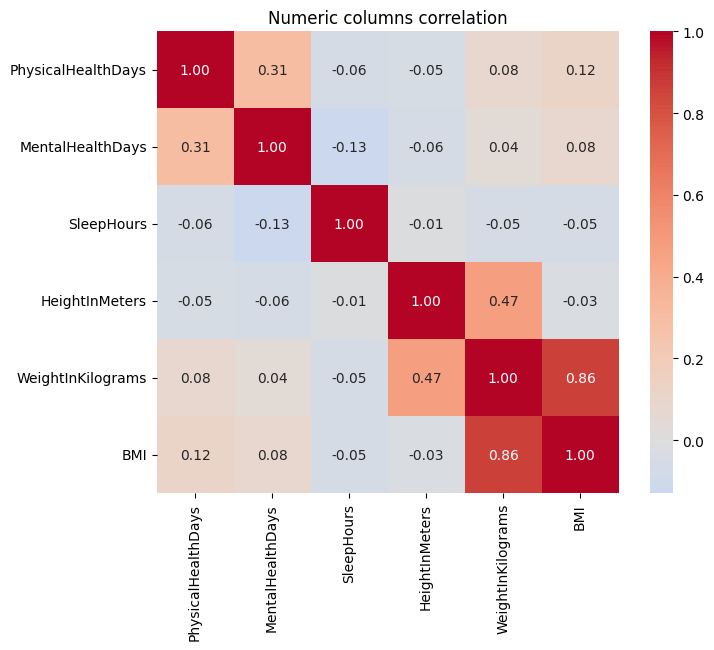

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    data[numeric_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True
)
plt.title('Numeric columns correlation')
plt.show()

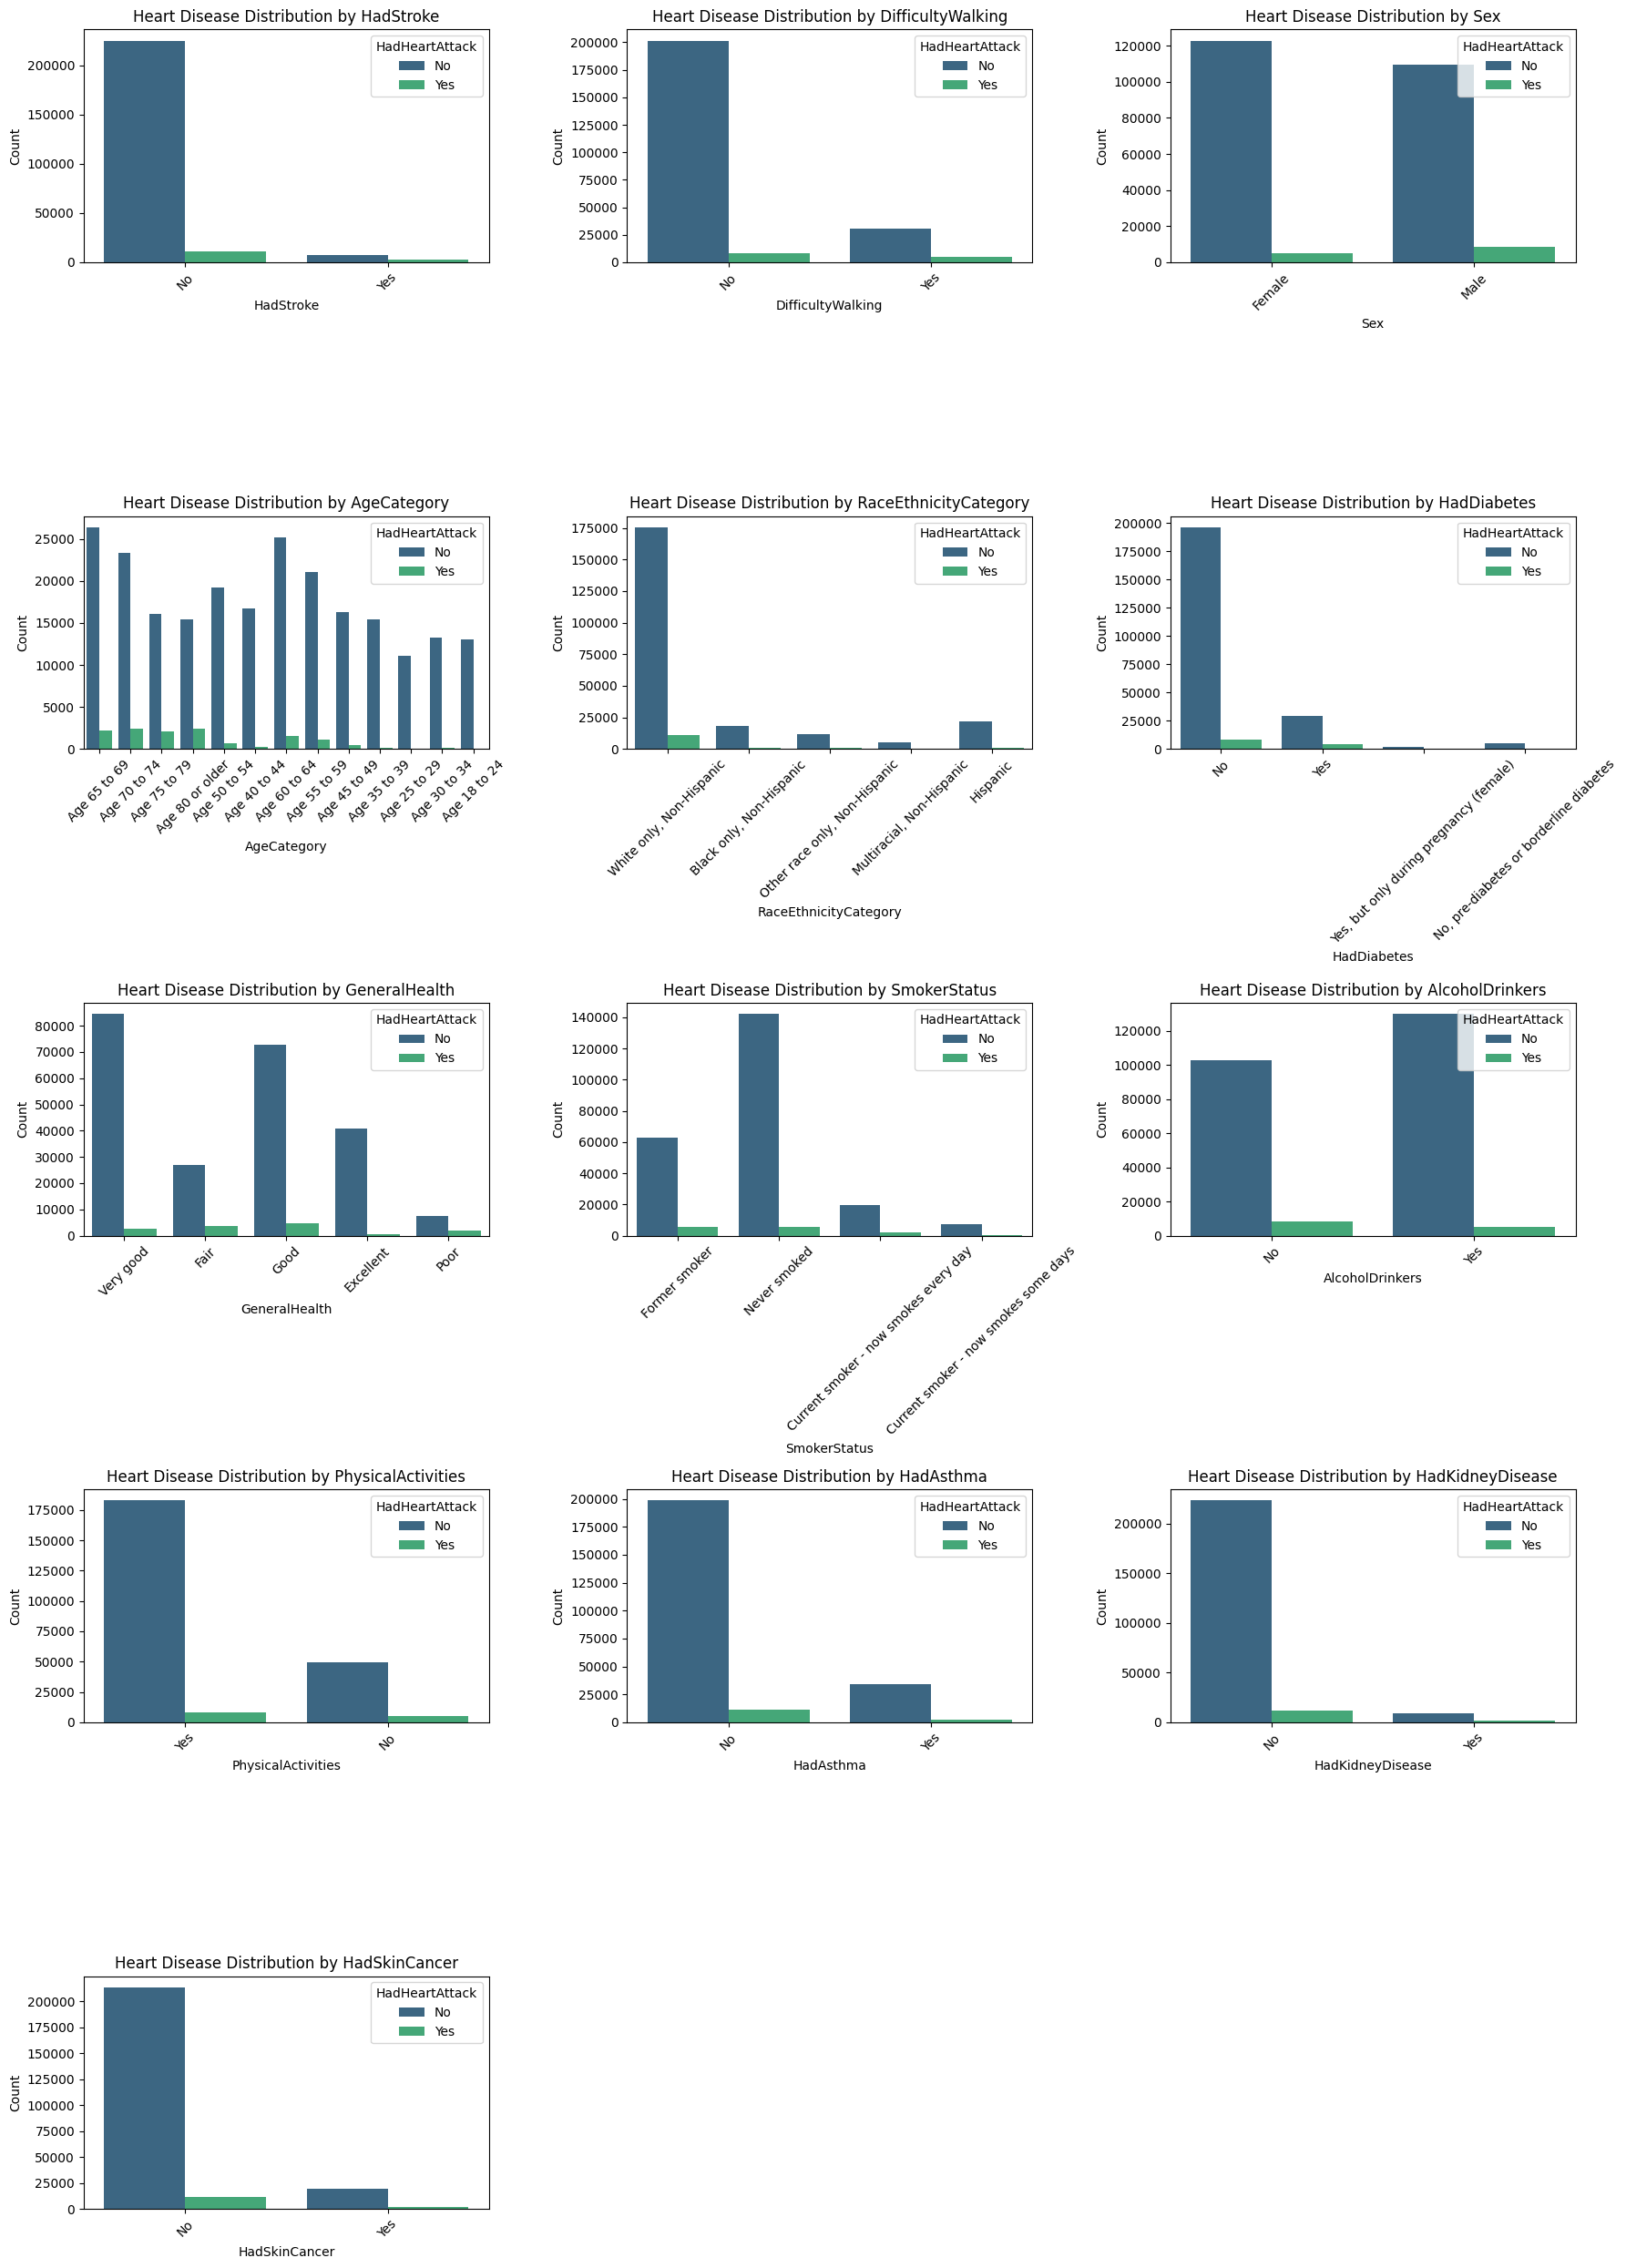

In [22]:
# Bar plots for categorical columns vs. HadHeartAttack in a single layout
categorical_cols = ['HadStroke', 'DifficultyWalking', 'Sex', 'AgeCategory', 'RaceEthnicityCategory', 'HadDiabetes', 'GeneralHealth', 'SmokerStatus', 'AlcoholDrinkers', 'PhysicalActivities', 'HadAsthma', 'HadKidneyDisease', 'HadSkinCancer']

n_cols = 3  # Number of columns for subplots
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols  # Calculate number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='HadHeartAttack', data=data, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Heart Disease Distribution by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='HadHeartAttack')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


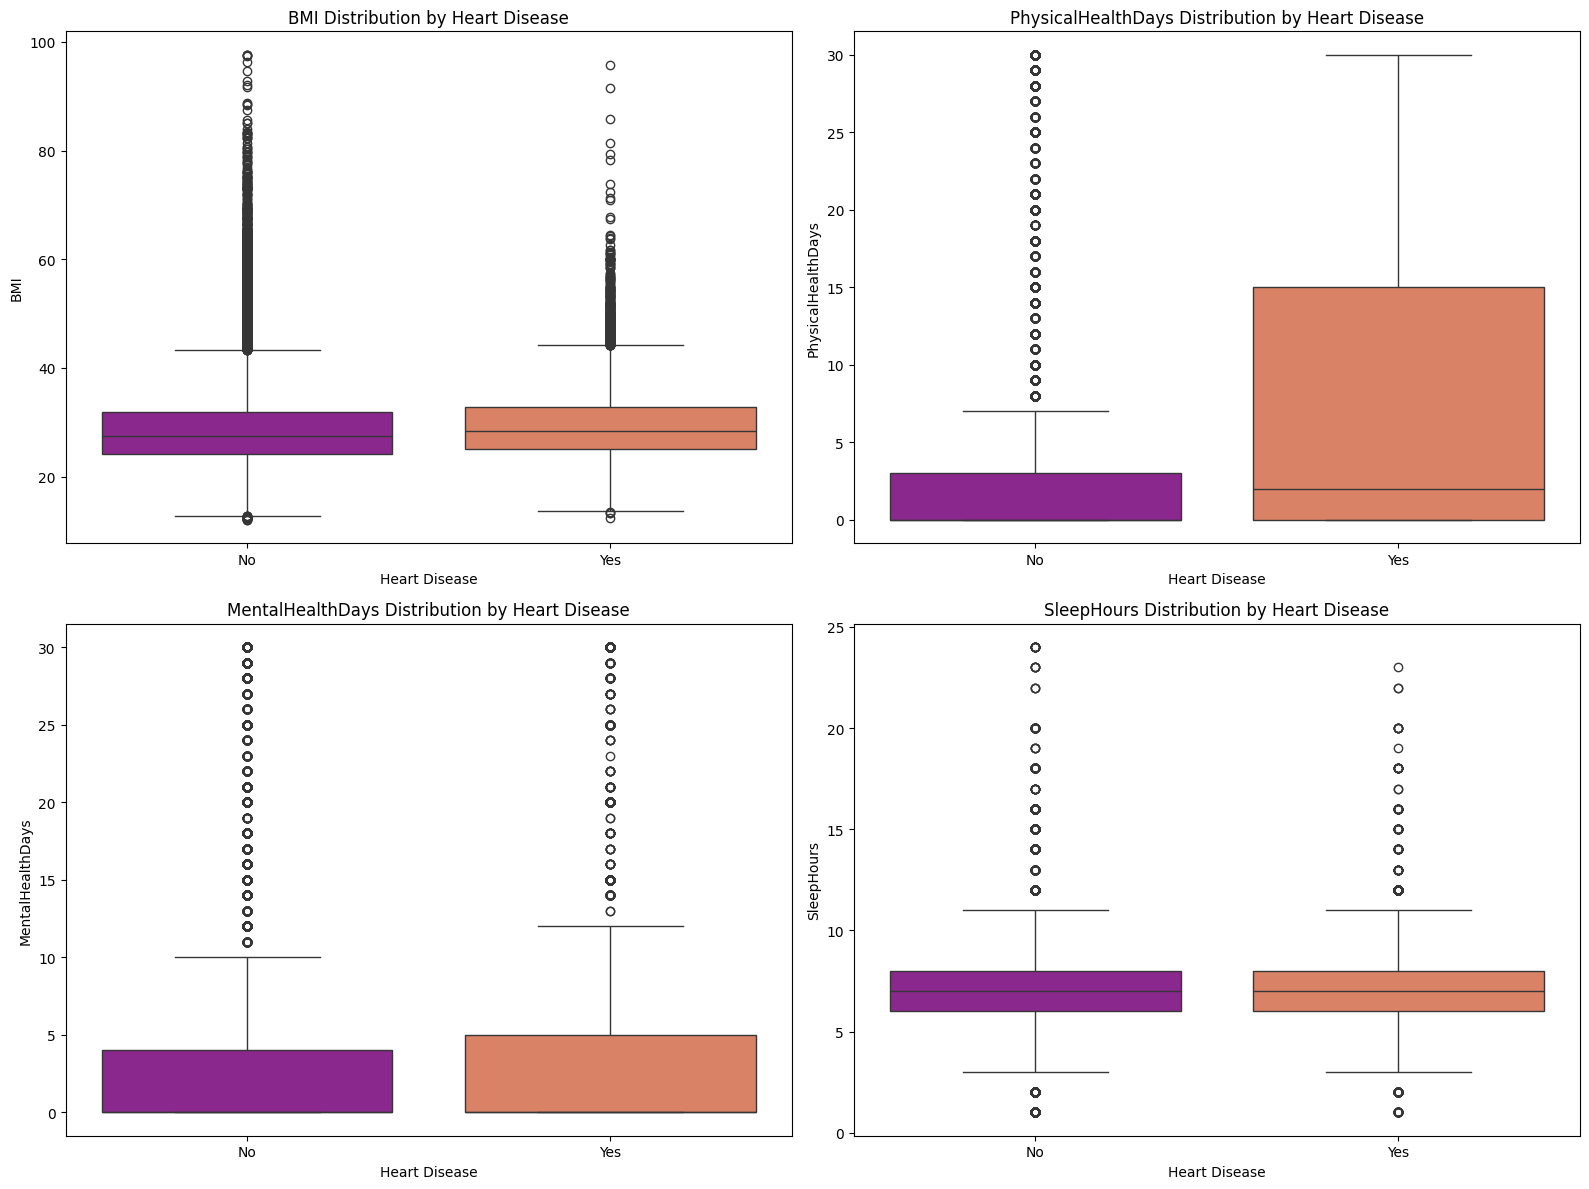

In [23]:

# Box plots for numerical columns vs. HadHeartAttack in a single layout
numerical_cols = ['BMI', 'PhysicalHealthDays', 'MentalHealthDays', 'SleepHours']
n_cols = 2  # Number of columns for subplots
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols  # Calculate number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 6))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='HadHeartAttack', y=col, data=data, palette='plasma', ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Heart Disease')
    axes[i].set_xlabel('Heart Disease')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

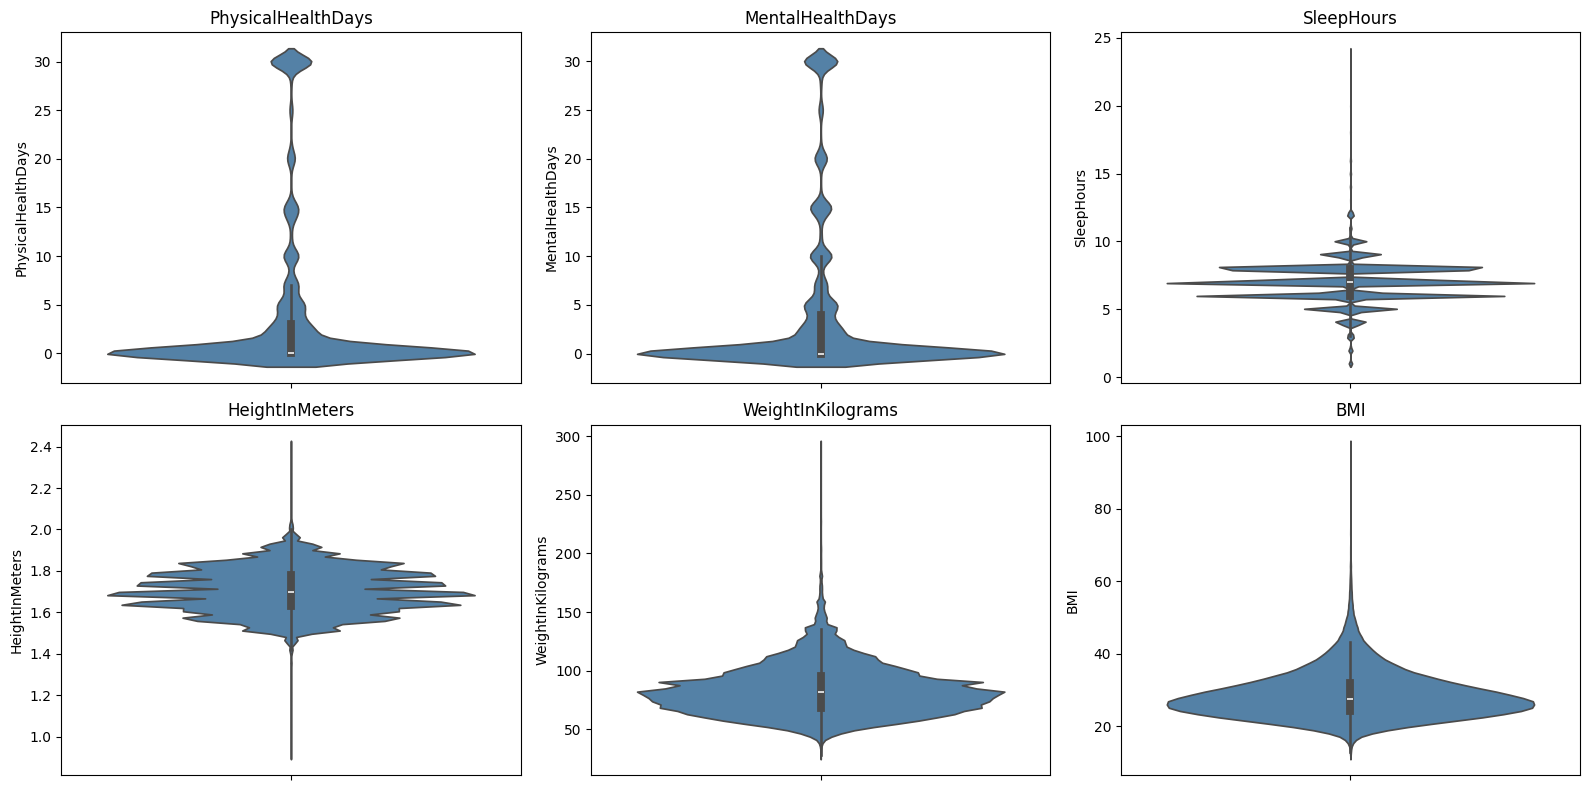

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.violinplot(y=data[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

#Pair Plot

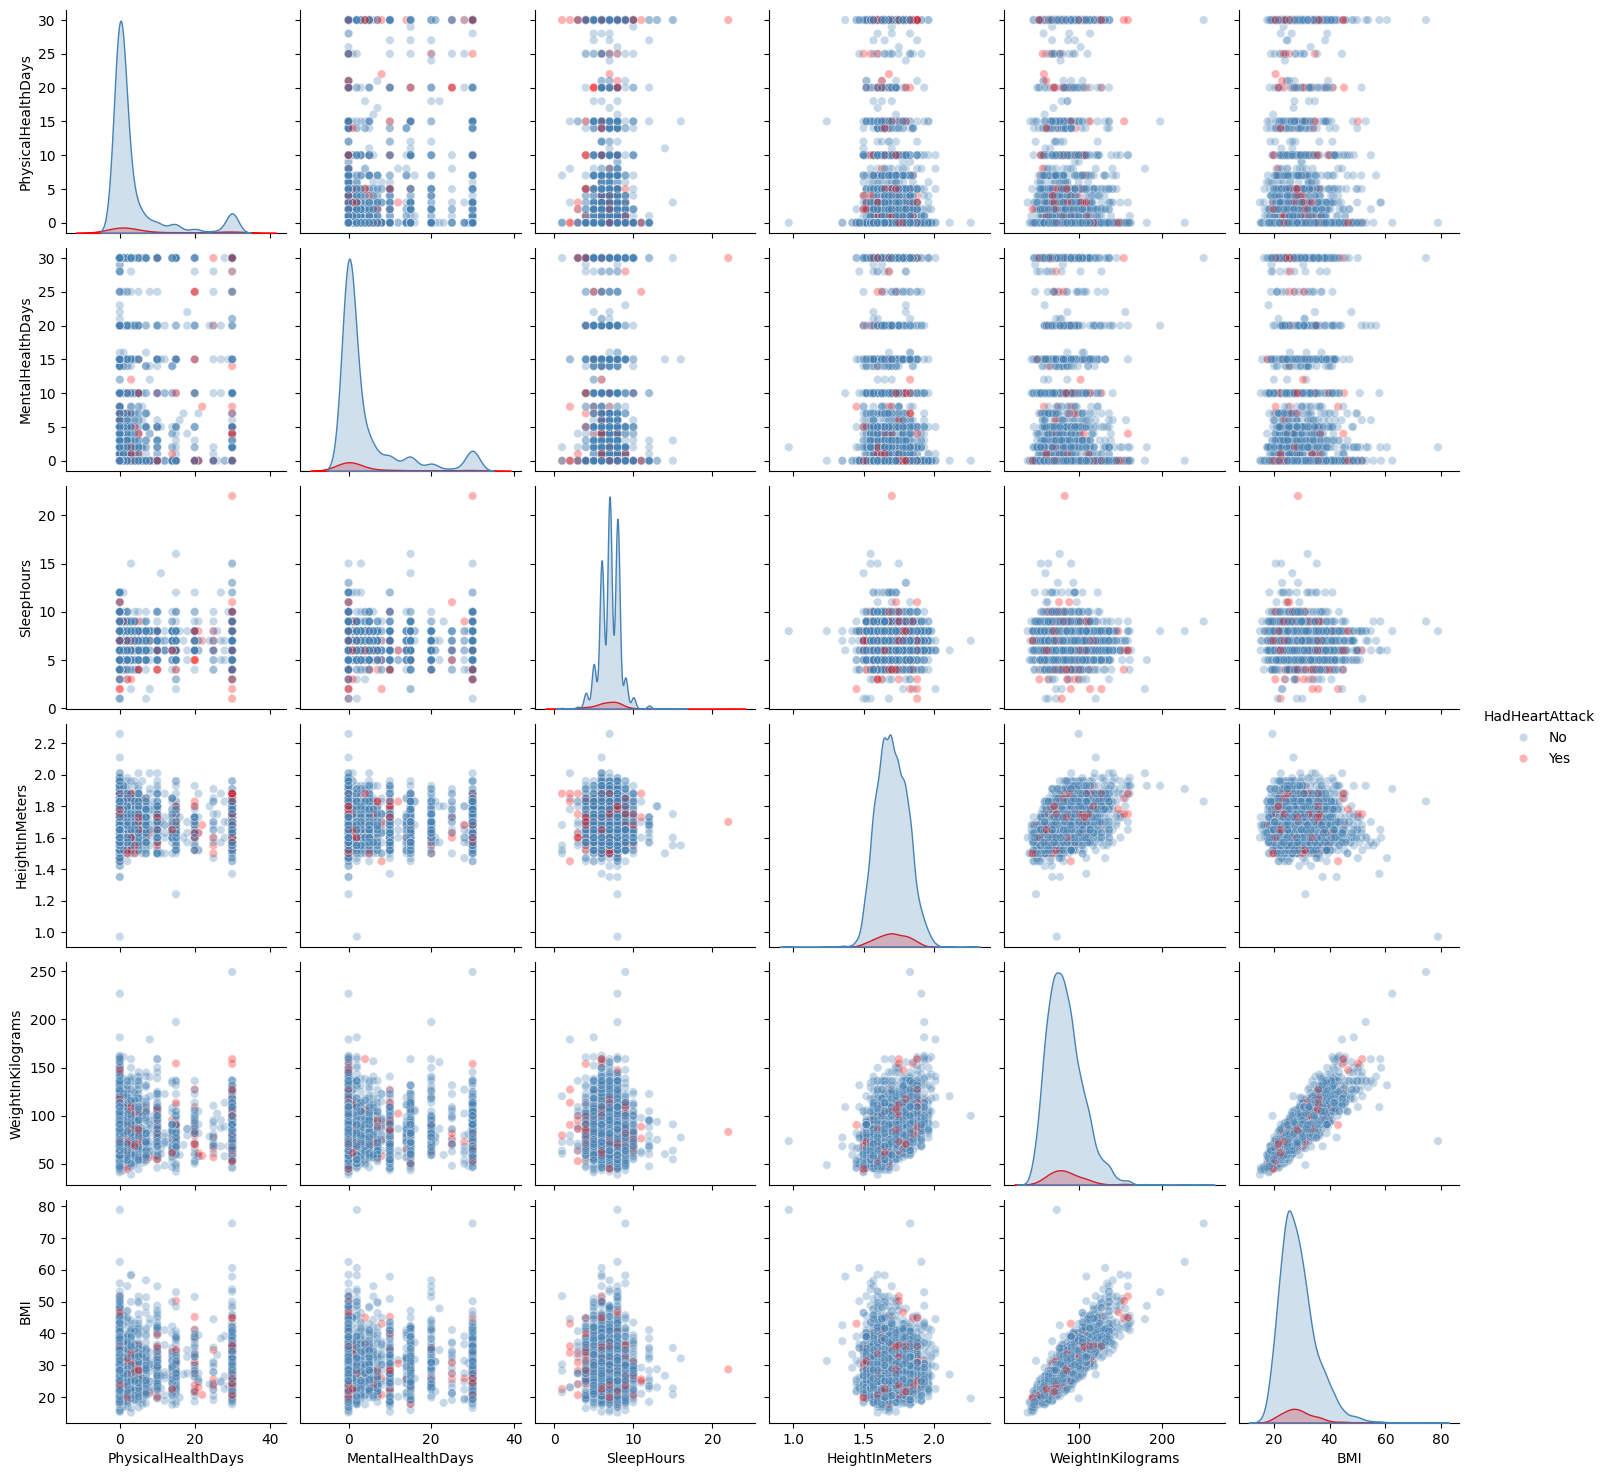

In [36]:
sample = data[numeric_cols + ['HadHeartAttack']].sample(3000, random_state=42)

sns.pairplot(
    sample,
    hue='HadHeartAttack',
    palette={'Yes': 'red', 'No': 'steelblue'},
    plot_kws={'alpha': 0.3},
    diag_kind='kde'
)
plt.show()

#Joint Distribution Plot

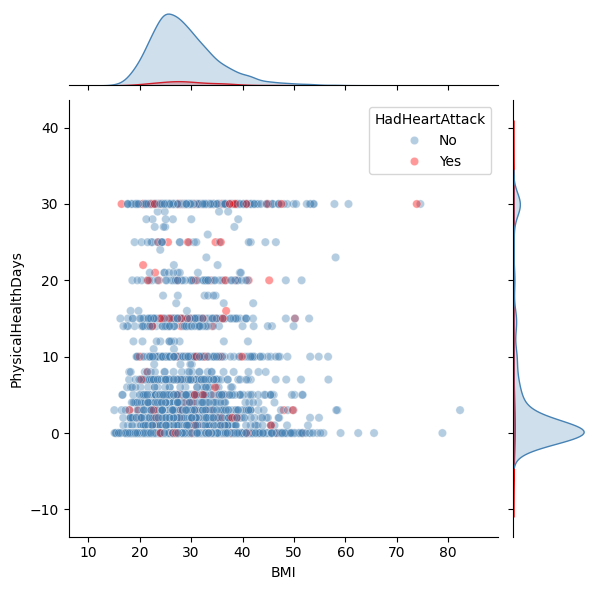

In [38]:
sns.jointplot(
    data=data.sample(5000, random_state=42),
    x='BMI', y='PhysicalHealthDays',
    hue='HadHeartAttack',
    palette={'Yes': 'red', 'No': 'steelblue'},
    alpha=0.4
)
plt.show()

#Parallel Coordinate Plot

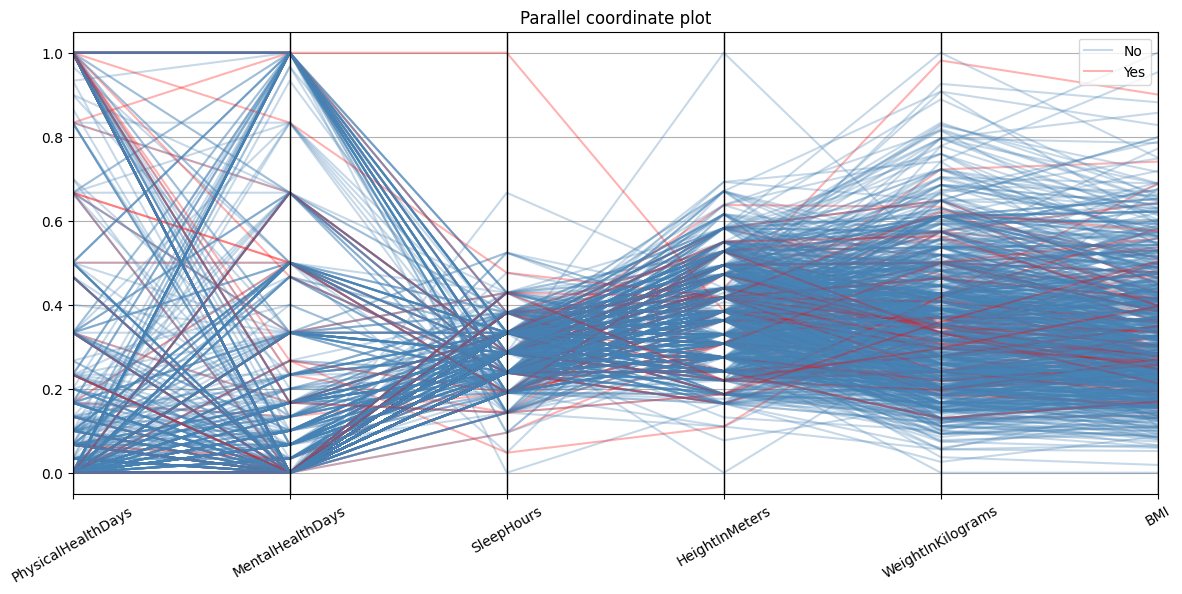

In [39]:
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

sample = data[numeric_cols + ['HadHeartAttack']].sample(1000, random_state=42).copy()
sample[numeric_cols] = MinMaxScaler().fit_transform(sample[numeric_cols])

plt.figure(figsize=(14, 6))
parallel_coordinates(sample, 'HadHeartAttack',
                     color=['steelblue', 'red'], alpha=0.3)
plt.xticks(rotation=30)
plt.title('Parallel coordinate plot')
plt.show()

Each line = one patient. Reveals which variable ranges separate heart attack cases from non-cases.